In [4]:
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, SubsetRandomSampler, Subset
from torch import optim
from TRPCA import trpca, utils
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm
import gc
from scipy.stats import ttest_ind
from itertools import combinations

In [5]:
table = pd.read_csv('data/control.csv', index_col=0)
age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})
shared_index = table.index.intersection(age_metadata.loc[(age_metadata.age.notna())&(age_metadata.body_site=='skin')].index)
table = table.loc[shared_index].drop(columns=['study_name','study_condition','subject_id'])
age_metadata = age_metadata.loc[shared_index]

table = (table*1000).round().astype(int)
df1 = np.log(table+1)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/116206118.py:2: DtypeWarning: Columns (21,22,25,28,29,30,32,33,35,38,51,52,53,54,55,56,57,58,63,64,65,67,68,69,74,75,76,80,90,91,92,93,96,104,105,108,109,111,112,116,117,118,119,120,121,126,128,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})


In [6]:
n_dimensions = 64
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

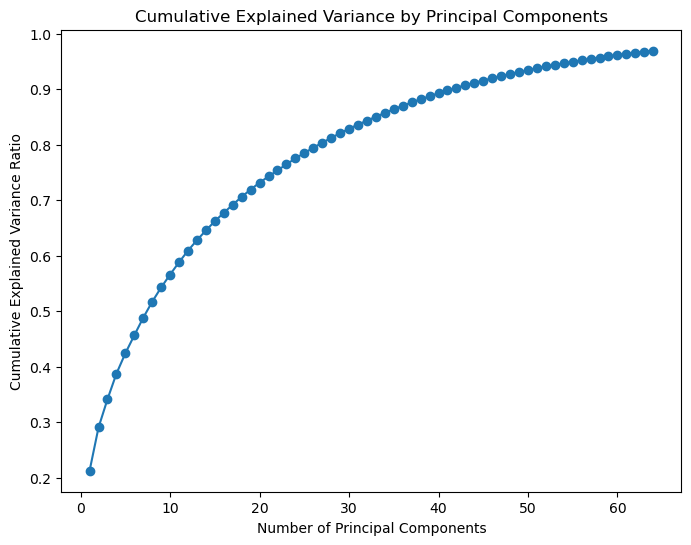

In [7]:
cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [8]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].age
df = df.loc[df.age.notna()]

In [9]:
age_metadata = age_metadata.loc[df.index]

In [16]:
# Parameters
num_folds = 5
batch_size = 16
epochs = 2000

# K-Fold Cross-Validator
kf = GroupKFold(n_splits=num_folds)
# kf = KFold(n_splits=num_folds)
# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X, y)
subjects = age_metadata.subject_id
original_indices = age_metadata.index.tolist()
# Loss function, model instantiation, etc., outside the loop
criterion = nn.L1Loss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []
# Cross-validation starts add y=y for kf split
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset, groups=subjects)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    # DataLoaders using the subsets directly
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)  # Shuffle here if needed
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.2, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.0003)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                outputs = regression_model(batch_features)
                loss = criterion(outputs['regression_output'], batch_labels)
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_preds = []
            all_y_true = []
            with torch.no_grad():
                for batch_features, batch_labels in val_loader:
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_y_true.extend(batch_labels.cpu().numpy())

            # # Update test predictions dictionary
            # test_predictions.update({idx: (pred, true) for idx, pred, true in zip(val_idx, all_preds, all_y_true)})
            # Map the integer indices back to the original string indices
            original_val_indices = [original_indices[i] for i in val_idx]

            # Update test predictions dictionary using original indices
            test_predictions.update({orig_idx: (pred, true) for orig_idx, pred, true in zip(original_val_indices, all_preds, all_y_true)})

    # Store the best validation loss of this fold and its associated training loss
    print(f"Best loss: {best_valid_loss}")  
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    torch.mps.empty_cache()
    gc.collect()
# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
predictions = [test_predictions[idx][0] for idx in indices]
true_values = [test_predictions[idx][1] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 38.9721, Val Loss: 39.5254
Epoch 2/2000, Train Loss: 38.9392, Val Loss: 39.5027
Epoch 3/2000, Train Loss: 38.9118, Val Loss: 39.4817
Epoch 4/2000, Train Loss: 38.8901, Val Loss: 39.4624
Epoch 5/2000, Train Loss: 38.8557, Val Loss: 39.4468
Epoch 6/2000, Train Loss: 38.8385, Val Loss: 39.4352
Epoch 7/2000, Train Loss: 38.8230, Val Loss: 39.4270
Epoch 8/2000, Train Loss: 38.8173, Val Loss: 39.4223
Epoch 9/2000, Train Loss: 38.8118, Val Loss: 39.4200
Epoch 10/2000, Train Loss: 38.8097, Val Loss: 39.4194
Epoch 11/2000, Train Loss: 38.8059, Val Loss: 39.3956
Epoch 12/2000, Train Loss: 38.7588, Val Loss: 39.3716
Epoch 13/2000, Train Loss: 38.7248, Val Loss: 39.3484
Epoch 14/2000, Train Loss: 38.7125, Val Loss: 39.3257
Epoch 15/2000, Train Loss: 38.6738, Val Loss: 39.3034
Epoch 16/2000, Train Loss: 38.6531, Val Loss: 39.2816
Epoch 17/2000, Train Loss: 38.6397, Val Loss: 39.2616
Epoch 18/2000, Train Loss: 38.6065, Val Loss: 39.2427
Epoch 19/2000, Train Loss: 38.5626, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 39.5303, Val Loss: 36.9370
Epoch 2/2000, Train Loss: 39.5001, Val Loss: 36.9091
Epoch 3/2000, Train Loss: 39.4957, Val Loss: 36.8827
Epoch 4/2000, Train Loss: 39.4694, Val Loss: 36.8597
Epoch 5/2000, Train Loss: 39.4445, Val Loss: 36.8407
Epoch 6/2000, Train Loss: 39.4026, Val Loss: 36.8257
Epoch 7/2000, Train Loss: 39.4004, Val Loss: 36.8155
Epoch 8/2000, Train Loss: 39.3880, Val Loss: 36.8095
Epoch 9/2000, Train Loss: 39.3871, Val Loss: 36.8067
Epoch 10/2000, Train Loss: 39.3793, Val Loss: 36.8059
Epoch 11/2000, Train Loss: 39.3748, Val Loss: 36.7763
Epoch 12/2000, Train Loss: 39.3485, Val Loss: 36.7462
Epoch 13/2000, Train Loss: 39.3109, Val Loss: 36.7163
Epoch 14/2000, Train Loss: 39.2740, Val Loss: 36.6866
Epoch 15/2000, Train Loss: 39.2303, Val Loss: 36.6566
Epoch 16/2000, Train Loss: 39.2220, Val Loss: 36.6266
Epoch 17/2000, Train Loss: 39.1757, Val Loss: 36.5986
Epoch 18/2000, Train Loss: 39.1565, Val Loss: 36.5727
Epoch 19/2000, Train Loss: 39.1023, V

...

Epoch 1/2000, Train Loss: 39.8876, Val Loss: 35.9746
Epoch 2/2000, Train Loss: 39.8608, Val Loss: 35.9448
Epoch 3/2000, Train Loss: 39.8217, Val Loss: 35.9175
Epoch 4/2000, Train Loss: 39.8005, Val Loss: 35.8935
Epoch 5/2000, Train Loss: 39.7858, Val Loss: 35.8734
Epoch 6/2000, Train Loss: 39.7600, Val Loss: 35.8581
Epoch 7/2000, Train Loss: 39.7446, Val Loss: 35.8476
Epoch 8/2000, Train Loss: 39.7410, Val Loss: 35.8414
Epoch 9/2000, Train Loss: 39.7369, Val Loss: 35.8385
Epoch 10/2000, Train Loss: 39.7241, Val Loss: 35.8377
Epoch 11/2000, Train Loss: 39.7088, Val Loss: 35.8069
Epoch 12/2000, Train Loss: 39.6777, Val Loss: 35.7755
Epoch 13/2000, Train Loss: 39.6588, Val Loss: 35.7451
Epoch 14/2000, Train Loss: 39.6374, Val Loss: 35.7157
Epoch 15/2000, Train Loss: 39.6054, Val Loss: 35.6875
Epoch 16/2000, Train Loss: 39.5707, Val Loss: 35.6603
Epoch 17/2000, Train Loss: 39.5383, Val Loss: 35.6347
Epoch 18/2000, Train Loss: 39.5115, Val Loss: 35.6113
Epoch 19/2000, Train Loss: 39.4844, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 38.1252, Val Loss: 42.0795
Epoch 2/2000, Train Loss: 38.0955, Val Loss: 42.0522
Epoch 3/2000, Train Loss: 38.0780, Val Loss: 42.0273
Epoch 4/2000, Train Loss: 38.0353, Val Loss: 42.0052
Epoch 5/2000, Train Loss: 38.0210, Val Loss: 41.9866
Epoch 6/2000, Train Loss: 37.9981, Val Loss: 41.9728
Epoch 7/2000, Train Loss: 37.9851, Val Loss: 41.9630
Epoch 8/2000, Train Loss: 37.9731, Val Loss: 41.9572
Epoch 9/2000, Train Loss: 37.9752, Val Loss: 41.9545
Epoch 10/2000, Train Loss: 37.9729, Val Loss: 41.9538
Epoch 11/2000, Train Loss: 37.9609, Val Loss: 41.9254
Epoch 12/2000, Train Loss: 37.9385, Val Loss: 41.8972
Epoch 13/2000, Train Loss: 37.8924, Val Loss: 41.8680
Epoch 14/2000, Train Loss: 37.8772, Val Loss: 41.8411
Epoch 15/2000, Train Loss: 37.8245, Val Loss: 41.8146
Epoch 16/2000, Train Loss: 37.8155, Val Loss: 41.7885
Epoch 17/2000, Train Loss: 37.7749, Val Loss: 41.7652
Epoch 18/2000, Train Loss: 37.7418, Val Loss: 41.7429
Epoch 19/2000, Train Loss: 37.7425, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 38.6872, Val Loss: 40.6809
Epoch 2/2000, Train Loss: 38.6674, Val Loss: 40.6508
Epoch 3/2000, Train Loss: 38.6325, Val Loss: 40.6238
Epoch 4/2000, Train Loss: 38.6119, Val Loss: 40.5999
Epoch 5/2000, Train Loss: 38.5836, Val Loss: 40.5802
Epoch 6/2000, Train Loss: 38.5759, Val Loss: 40.5650
Epoch 7/2000, Train Loss: 38.5602, Val Loss: 40.5548
Epoch 8/2000, Train Loss: 38.5386, Val Loss: 40.5485
Epoch 9/2000, Train Loss: 38.5428, Val Loss: 40.5456
Epoch 10/2000, Train Loss: 38.5428, Val Loss: 40.5449
Epoch 11/2000, Train Loss: 38.5143, Val Loss: 40.5142
Epoch 12/2000, Train Loss: 38.4844, Val Loss: 40.4855
Epoch 13/2000, Train Loss: 38.4632, Val Loss: 40.4558
Epoch 14/2000, Train Loss: 38.4401, Val Loss: 40.4272
Epoch 15/2000, Train Loss: 38.3971, Val Loss: 40.3996
Epoch 16/2000, Train Loss: 38.3687, Val Loss: 40.3738
Epoch 17/2000, Train Loss: 38.3445, Val Loss: 40.3502
Epoch 18/2000, Train Loss: 38.3058, Val Loss: 40.3279
Epoch 19/2000, Train Loss: 38.3112, V

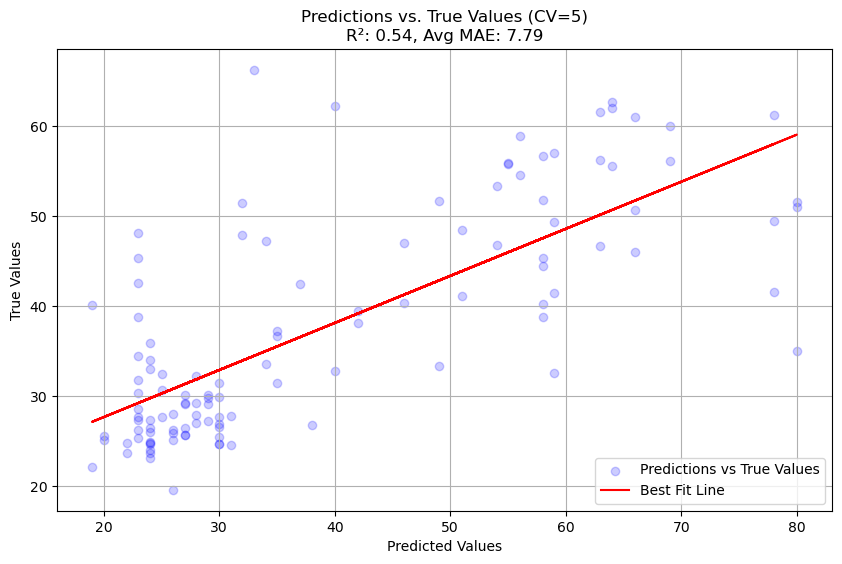

In [17]:
predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.legend()
plt.grid(True)  # Optional: Adds grid for better visualization
plt.show()

### Residual analysis for metadata categories. (sex, body site, diet, disease, country of birth, acne, antibiotics, etc. )

In [18]:
# Extract predictions, true values, and original indices
predictions = [pred for _, (pred, _) in test_predictions.items()]
true_values = [true for _, (_, true) in test_predictions.items()]
indices = list(test_predictions.keys())

# Step 1: Calculate the absolute error
absolute_errors = [(pred - true)[0] for pred, true in zip(predictions, true_values)]

# Step 2: Create a DataFrame with the errors and ensure it has a common index column
error_df = pd.DataFrame({'original_index': indices, 'absolute_error': absolute_errors})

# Ensure 'original_index' in error_df is of type string for merging
error_df['original_index'] = error_df['original_index'].astype(str)

# Step 3: Ensure age_metadata has an index column that matches the original indices
age_metadata['original_index'] = age_metadata.index.astype(str)

# Merge the DataFrames using the common column 'original_index'
merged_df = pd.merge(age_metadata, error_df, on='original_index', how='inner')

In [19]:
# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'
    
def plot_residual_violin(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))
    ax = sns.violinplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", hue=metadata_column, legend=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.05, jitter=True)
    plt.title(f'Violin Plot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    categories = merged_df[metadata_column].unique()
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_distribution(metadata_column, merged_df):
    plt.figure(figsize=(10, 10))

    # Plot distributions
    categories = merged_df[metadata_column].unique()
    colors = sns.color_palette("muted", len(categories))
    
    for category, color in zip(categories, colors):
        subset = merged_df[merged_df[metadata_column] == category]
        sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
    
    plt.title(f'Distribution of Prediction Errors by {metadata_column}')
    plt.xlabel('Absolute Error')
    plt.ylabel('Density')

    # Perform a statistical test between all groups
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = 0.06  # Density plots typically max out at 1
    y_min = 0
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis for annotations
    category_positions = {category: np.mean(merged_df[merged_df[metadata_column] == category]['absolute_error']) for category in categories}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.legend(title=metadata_column)
    plt.show()

# Example usage:
# plot_residual_distribution('your_metadata_column', your_merged_df)


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import ttest_ind
import numpy as np

# Function to determine the significance level based on p-value
def get_significance_label(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def plot_residual_boxplot(metadata_column, merged_df):
    plt.figure(figsize=(8, 8))

    # Plot boxplot
    ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)
    sns.stripplot(x=metadata_column, y='absolute_error', data=merged_df, color='k', alpha=0.5, jitter=True)

    plt.title(f'Boxplot of Prediction Errors by {metadata_column}')
    plt.xlabel(metadata_column)
    plt.ylabel('Absolute Error')

    # Perform a statistical test between all groups
    categories = merged_df[metadata_column].unique()
    group_combinations = list(combinations(categories, 2))
    p_values = []
    for comb in group_combinations:
        group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
        group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
        t_stat, p_val = ttest_ind(group1, group2)
        p_values.append((comb, p_val))
        print(f'Comparison {comb[0]} vs {comb[1]}: p-value = {p_val}')

    # Add significance annotations to the plot
    y_max = merged_df['absolute_error'].max()
    y_min = merged_df['absolute_error'].min()
    y_range = y_max - y_min
    y_buffer = 0.05 * y_range

    # Mapping categories to their positions on the x-axis
    category_positions = {category: i for i, category in enumerate(categories)}

    # Initialize a variable to keep track of the y position
    y_position = y_max + y_buffer

    for (comb, p_val) in p_values:
        x1, x2 = category_positions[comb[0]], category_positions[comb[1]]
        y, h = y_position, y_buffer
        significance_label = get_significance_label(p_val)
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='k')
        plt.text((x1 + x2) / 2, y + h, significance_label, ha='center', va='bottom', color='k')
        y_position += y_buffer * 2  # Increment y position to avoid overlap

    plt.show()

# Example usage:
# plot_residual_boxplot('your_metadata_column', your_merged_df)


In [22]:
age_metadata

,study_name,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,infant_age,age_category,gender,...,hla_dqa11,hla_drb11,zigosity,brinkman_index,alcohol_numeric,breastfeeding_duration,formula_first_day,ALT,eGFR,original_index
WBE005,ChngKR_2016,Sub1,skin,NaN,control,healthy,30.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WBE005
WBE006,ChngKR_2016,Sub1,skin,NaN,control,healthy,30.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WBE006
WBE007,ChngKR_2016,Sub2,skin,NaN,control,healthy,29.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WBE007
WBE008,ChngKR_2016,Sub2,skin,NaN,control,healthy,29.0,NaN,adult,female,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WBE008
WBE017,ChngKR_2016,Sub3,skin,NaN,control,healthy,28.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WBE017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Steph_b2_66,TettAJ_2016,TettAJ_201620,skin,no,control,psoriasis,49.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Steph_b2_66
Steph_b2_67,TettAJ_2016,TettAJ_201620,skin,no,control,psoriasis,49.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Steph_b2_67
Steph_b2_70,TettAJ_2016,TettAJ_201621,skin,no,control,psoriasis,58.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Steph_b2_70
Steph_b2_72,TettAJ_2016,TettAJ_201621,skin,no,control,psoriasis,58.0,NaN,adult,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Steph_b2_72


In [23]:
# Function to check if a column has significant results
def check_significance(metadata_column, merged_df):
    merged_df = merged_df.dropna(subset=[metadata_column])
    if len(merged_df[metadata_column].unique())<10:
        # Perform a statistical test between all groups
        group_combinations = list(combinations(merged_df[metadata_column].unique(), 2))
        for comb in group_combinations:
            group1 = merged_df[merged_df[metadata_column] == comb[0]]['absolute_error']
            group2 = merged_df[merged_df[metadata_column] == comb[1]]['absolute_error']
            t_stat, p_val = ttest_ind(group1, group2)
            if p_val < 0.05:
                return True
        return False
    else:
        return False
    
# Iterate through each column in age_metadata and run the analysis
significant_columns = []

for column in tqdm(age_metadata.columns, total=len(age_metadata.columns)):
    if check_significance(column, merged_df):
        significant_columns.append(column)

# Output the list of significant columns
print("Number of Significant columns:", len(significant_columns))

  0%|          | 0/141 [00:00<?, ?it/s]

Number of Significant columns: 8


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/2584679727.py:10: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_val = ttest_ind(group1, group2)
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [28]:
significant_columns

['study_name',
 'disease',
 'age_category',
 'country',
 'DNA_extraction_kit',
 'PMID',
 'minimum_read_length',
 'body_subsite']

In [34]:
# merged_df.to_csv('data/wgs_skin_residuals.tsv', sep='\t', index=True)

Comparison IDN vs SGP: p-value = 0.08990848669854956
Comparison IDN vs CHN: p-value = 0.021767237969090514
Comparison IDN vs MYS: p-value = 0.000346942563065844
Comparison IDN vs BRN: p-value = 0.24570117355145515
Comparison IDN vs USA: p-value = 0.17017084249983153
Comparison IDN vs ITA: p-value = 0.7577933263084937
Comparison SGP vs CHN: p-value = 0.07285929726165942
Comparison SGP vs MYS: p-value = 0.33214482674318613
Comparison SGP vs BRN: p-value = 0.6127370154264271
Comparison SGP vs USA: p-value = 0.08174203911452368
Comparison SGP vs ITA: p-value = 0.013853771127970057
Comparison CHN vs MYS: p-value = 0.5339533079232188
Comparison CHN vs BRN: p-value = 0.193964837342422
Comparison CHN vs USA: p-value = 0.5320542634584047
Comparison CHN vs ITA: p-value = 0.0021572218631208703
Comparison MYS vs BRN: p-value = 0.06467247480722606
Comparison MYS vs USA: p-value = 0.4792875105903007
Comparison MYS vs ITA: p-value = 0.06278441939190295
Comparison BRN vs USA: p-value = 0.3907170227372

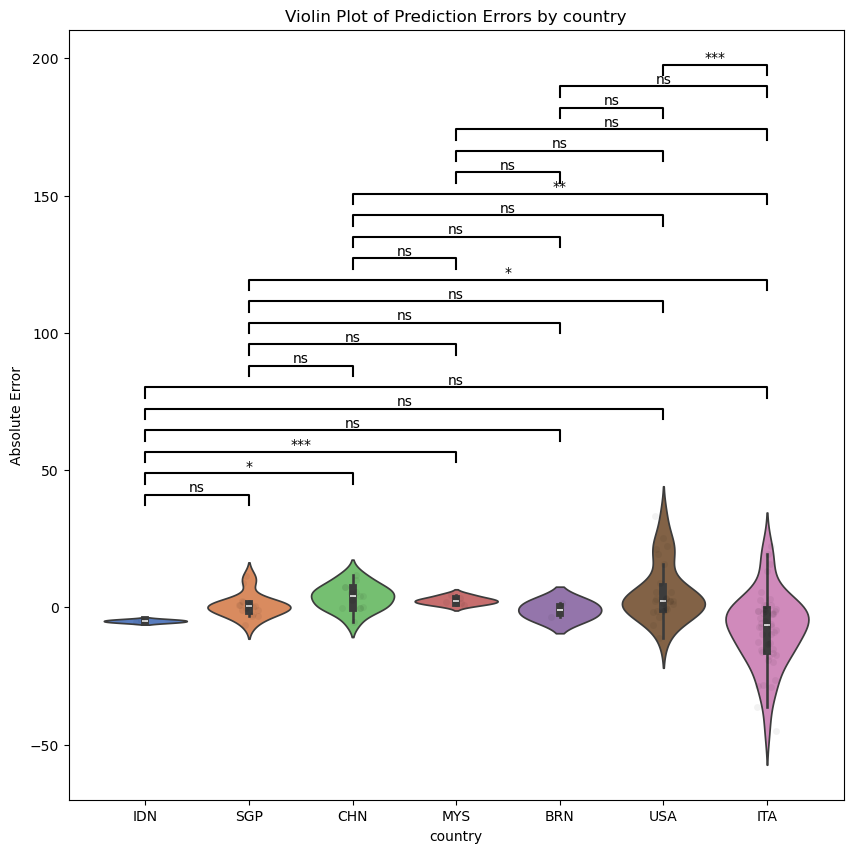

In [29]:
plot_residual_violin('country', merged_df.loc[merged_df.country.notna()])

Comparison IDN vs SGP: p-value = 0.08990848669854956
Comparison IDN vs CHN: p-value = 0.021767237969090514
Comparison IDN vs MYS: p-value = 0.000346942563065844
Comparison IDN vs BRN: p-value = 0.24570117355145515
Comparison IDN vs USA: p-value = 0.17017084249983153
Comparison IDN vs ITA: p-value = 0.7577933263084937
Comparison SGP vs CHN: p-value = 0.07285929726165942
Comparison SGP vs MYS: p-value = 0.33214482674318613
Comparison SGP vs BRN: p-value = 0.6127370154264271
Comparison SGP vs USA: p-value = 0.08174203911452368
Comparison SGP vs ITA: p-value = 0.013853771127970057
Comparison CHN vs MYS: p-value = 0.5339533079232188
Comparison CHN vs BRN: p-value = 0.193964837342422
Comparison CHN vs USA: p-value = 0.5320542634584047
Comparison CHN vs ITA: p-value = 0.0021572218631208703
Comparison MYS vs BRN: p-value = 0.06467247480722606
Comparison MYS vs USA: p-value = 0.4792875105903007
Comparison MYS vs ITA: p-value = 0.06278441939190295
Comparison BRN vs USA: p-value = 0.3907170227372

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/4157708794.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['absolute_error'], shade=True, color=color, label=category)
/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m

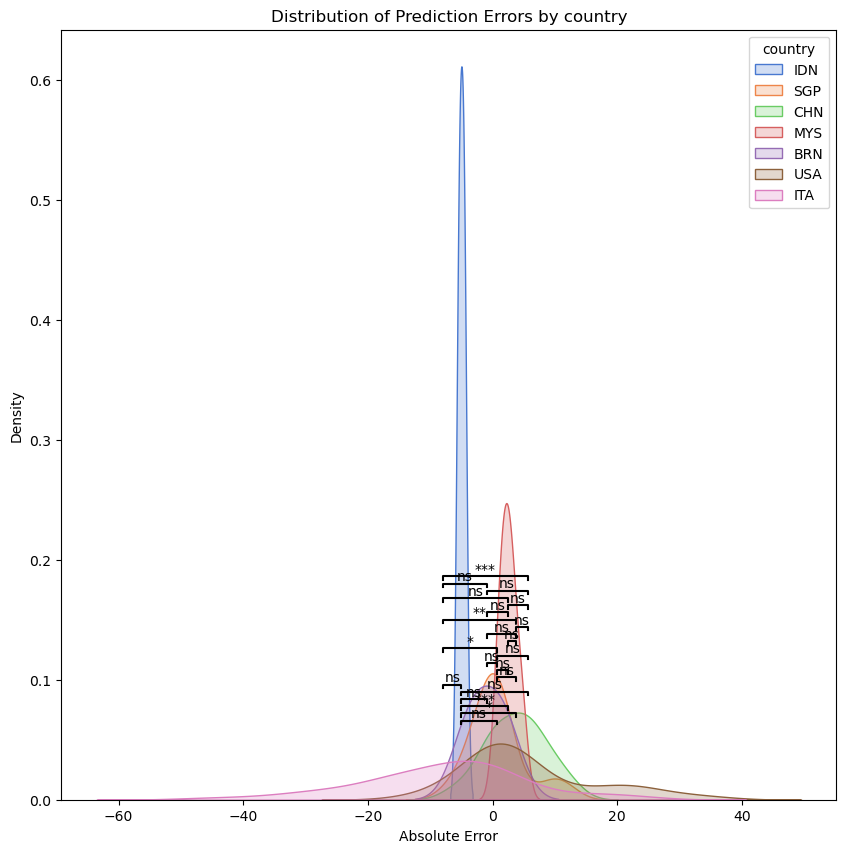

In [30]:
plot_residual_distribution('country', merged_df.loc[merged_df.country.notna()])

In [32]:
country_list = ['IDN', 'CHN', 'MYS', 'SGP', 'ITA', 'USA']

Comparison IDN vs SGP: p-value = 0.08990848669854956
Comparison IDN vs CHN: p-value = 0.021767237969090514
Comparison IDN vs MYS: p-value = 0.000346942563065844
Comparison IDN vs USA: p-value = 0.17017084249983153
Comparison IDN vs ITA: p-value = 0.7577933263084937
Comparison SGP vs CHN: p-value = 0.07285929726165942
Comparison SGP vs MYS: p-value = 0.33214482674318613
Comparison SGP vs USA: p-value = 0.08174203911452368
Comparison SGP vs ITA: p-value = 0.013853771127970057
Comparison CHN vs MYS: p-value = 0.5339533079232188
Comparison CHN vs USA: p-value = 0.5320542634584047
Comparison CHN vs ITA: p-value = 0.0021572218631208703
Comparison MYS vs USA: p-value = 0.4792875105903007
Comparison MYS vs ITA: p-value = 0.06278441939190295
Comparison USA vs ITA: p-value = 2.126774533294329e-05


/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_63832/680936819.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x=metadata_column, y='absolute_error', data=merged_df, palette="muted", showfliers=False)


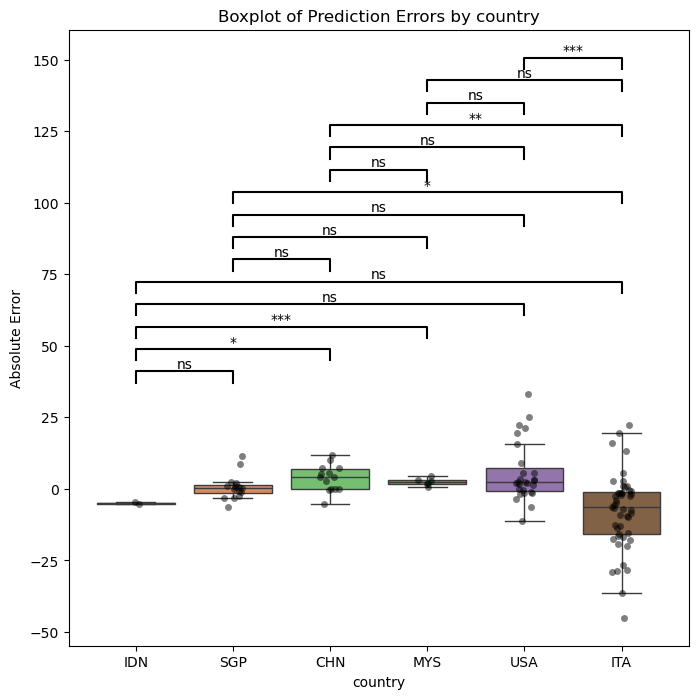

In [33]:
plot_residual_boxplot('country', merged_df.loc[merged_df.country.isin(country_list)])